# Toy example — D=3 Gaussian chain

In [1]:
import os
import sys
import pickle

import numpy as np
import matplotlib.pyplot as plt

# Make the repo root importable so `models...` resolves regardless of CWD.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from models.ddpm.core.ddpm_torch.toy import GaussianDiffusion, get_beta_schedule

# Diffusion schedule (must match the one used to compute the Hessians)
betas = get_beta_schedule("linear", beta_start=0.001, beta_end=0.2, timesteps=500)
diffusion = GaussianDiffusion(
    betas=betas, model_mean_type="eps", model_var_type="fixed-large", loss_type="mse")

# Per-timestep diffusion coefficients on the t = 1..30 grid
t_list = list(range(1, 31))
alpha_bar = np.asarray(diffusion.alphas_bar)[t_list]
mu_t = np.sqrt(alpha_bar)            # μ_t
sigma_t = np.sqrt(1.0 - alpha_bar)   # σ_t

## Ground truth and the diffused precision

In [2]:
a, b = 0.7, 0.5
Omega_0 = np.array([
    [1.0, a,   0.0],
    [a,   1.0, b],
    [0.0, b,   1.0],
])
Sigma_0 = np.linalg.inv(Omega_0)
D = Omega_0.shape[0]

print("True precision Omega_0:")
print(Omega_0)
print("\nTrue covariance Sigma_0:")
print(Sigma_0)

# Theoretical Omega_t off-diagonals on the discrete grid
pairs = [(i, j) for i in range(D) for j in range(i + 1, D)]
omega_traces = {p: [] for p in pairs}
for k in range(len(t_list)):
    Sigma_t = mu_t[k] ** 2 * Sigma_0 + sigma_t[k] ** 2 * np.eye(D)
    Omega_t = np.linalg.inv(Sigma_t)
    for (i, j) in pairs:
        omega_traces[(i, j)].append(Omega_t[i, j])
for key in omega_traces:
    omega_traces[key] = np.array(omega_traces[key])

True precision Omega_0:
[[1.  0.7 0. ]
 [0.7 1.  0.5]
 [0.  0.5 1. ]]

True covariance Sigma_0:
[[ 2.88461538 -2.69230769  1.34615385]
 [-2.69230769  3.84615385 -1.92307692]
 [ 1.34615385 -1.92307692  1.96153846]]


## Load the estimated Hessians

In [3]:
DATA_DIR = "./data/hessian_dim3_prec75_gau"
sample_dirs = ["n10", "n20", "n50", "n500"]
n_values = [10, 20, 50, 500]

hessian_data = {}
for nd in sample_dirs:
    with open(os.path.join(DATA_DIR, f"{nd}.pickle"), "rb") as f:
        hessian_data[nd] = pickle.load(f)
    n_t = max(hessian_data[nd][0].keys())
    print(f"loaded {nd}: timesteps 1..{n_t}")

entry_keys = [(i, j) for i in range(D) for j in range(i + 1, D)]
entry_labels = [r"$(1,2)$", r"$(1,3)$", r"$(2,3)$"]
colors = plt.cm.tab10(np.linspace(0, 1, len(entry_keys)))


def standardize_across_entries(data0, t_list, entry_keys):
    """Per-timestep z-score of the off-diagonal entries across the 3 pairs."""
    result = {k: [] for k in entry_keys}
    for t in t_list:
        vals = np.array([data0[t][i, j] for (i, j) in entry_keys])
        mu, sd = vals.mean(), vals.std()
        for (i, j), v in zip(entry_keys, vals):
            result[(i, j)].append((v - mu) / sd if sd > 0 else v - mu)
    return result


def standardize_omega_across_entries(omega_traces, entry_keys, n_t):
    """Same per-timestep standardization for the theoretical |Omega_t|."""
    arr = np.array([np.abs(omega_traces[(i, j)])[:n_t] for (i, j) in entry_keys])
    mu = arr.mean(axis=0)
    sd = arr.std(axis=0)
    sd[sd == 0] = 1.0
    return {(i, j): (arr[k] - mu) / sd for k, (i, j) in enumerate(entry_keys)}

loaded n10: timesteps 1..50
loaded n20: timesteps 1..50
loaded n50: timesteps 1..50
loaded n500: timesteps 1..50


## Figure - estimation results for the $3$-dimensional Gaussian distribution with varying $n$ (before standardization)

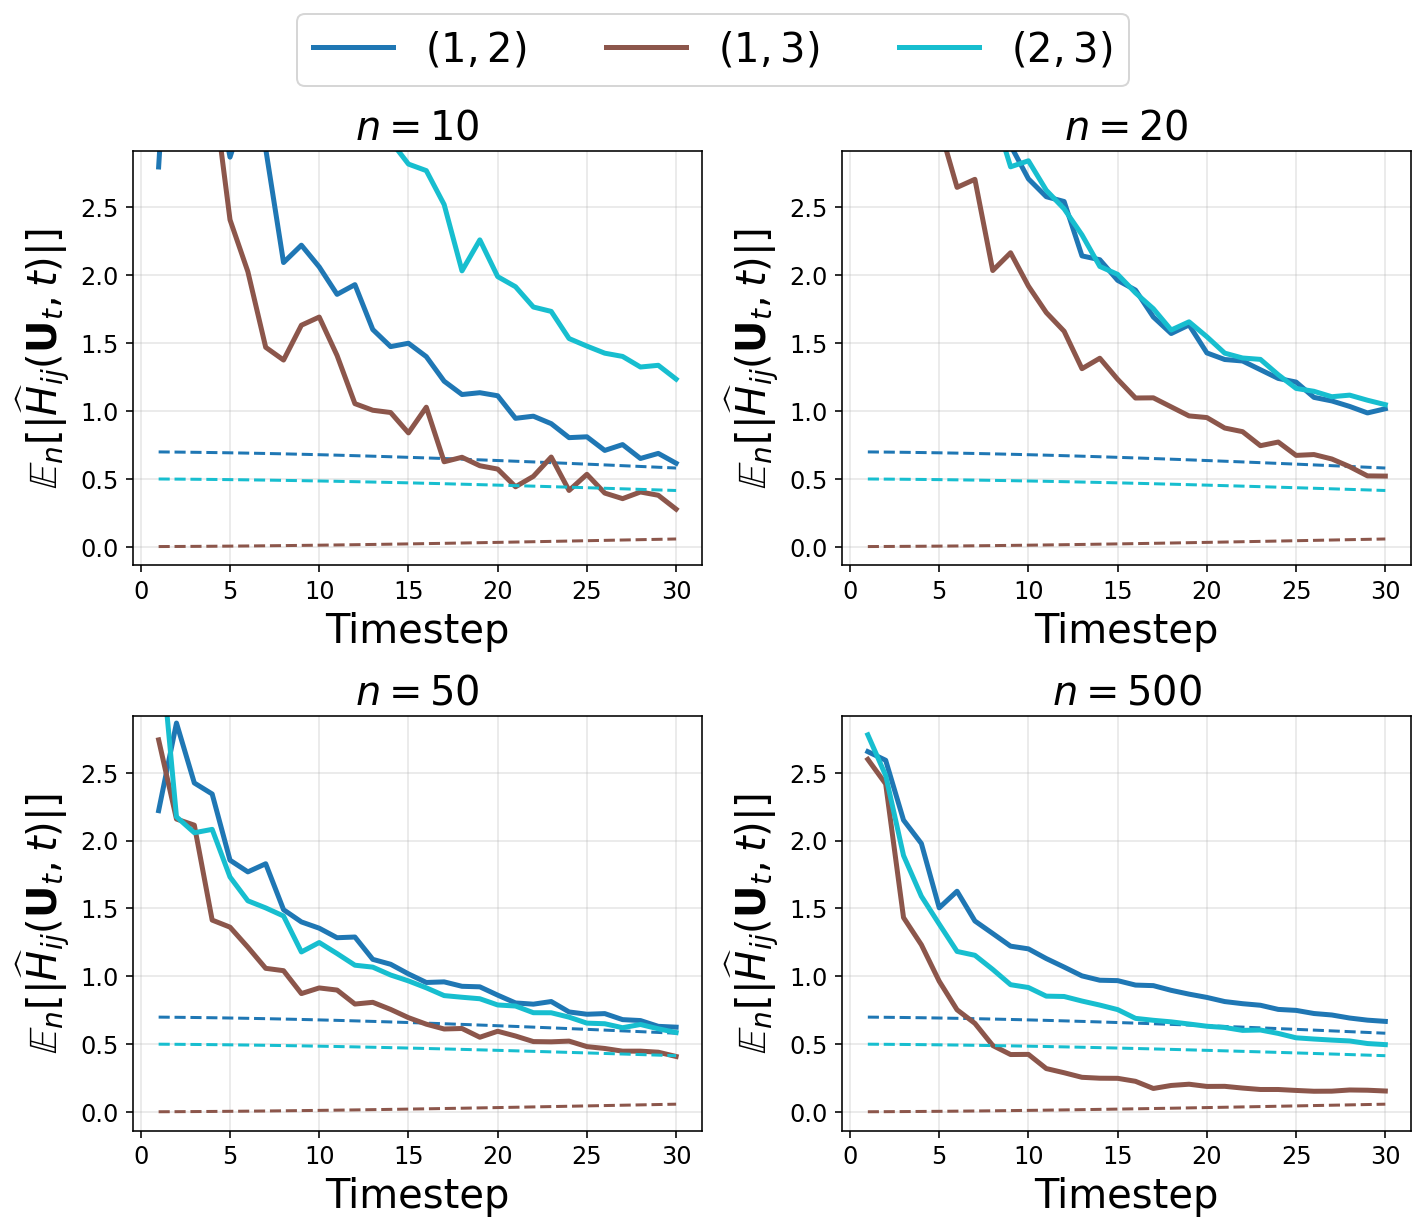

In [4]:
# Shared y-limits from the largest sample size
data0_n500 = hessian_data["n500"][0]
t_list_n500 = sorted(data0_n500.keys())[:30]
all_vals = []
for (i, j) in entry_keys:
    all_vals.extend([data0_n500[t][i, j] for t in t_list_n500])
    all_vals.extend(list(np.abs(omega_traces[(i, j)])))
margin = (max(all_vals) - min(all_vals)) * 0.05
shared_ylim = (min(all_vals) - margin, max(all_vals) + margin)

ncols = len(hessian_data) // 2 + len(hessian_data) % 2
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 8), squeeze=False)
axes = axes.flatten()

legend_handles = []
for ax_idx, nd in enumerate(hessian_data):
    data0 = hessian_data[nd][0]
    tl = sorted(data0.keys())[:30]
    ax = axes[ax_idx]
    for c_idx, (i, j) in enumerate(entry_keys):
        line, = ax.plot(tl, [data0[t][i, j] for t in tl],
                        color=colors[c_idx], linewidth=2.5, label=entry_labels[c_idx])
        ax.plot(tl, np.abs(omega_traces[(i, j)]),
                color=colors[c_idx], linewidth=1.5, linestyle="--")
        if ax_idx == 0:
            legend_handles.append(line)
    ax.set_title(rf"$n={n_values[ax_idx]}$", fontsize=20)
    ax.set_xlabel("Timestep", fontsize=20)
    ax.set_ylabel(r"$\mathbb{E}_{n}[\vert \widehat H_{ij}(\mathbf{U}_{t}, t)\vert]$", fontsize=20)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(shared_ylim)

for k in range(len(hessian_data), len(axes)):
    axes[k].set_visible(False)

fig.legend(legend_handles, entry_labels, loc="upper center",
           ncol=len(legend_handles), fontsize=20, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

## Figure - estimation results for the $3$-dimensional Gaussian distribution with varying $n$ (after standardization)

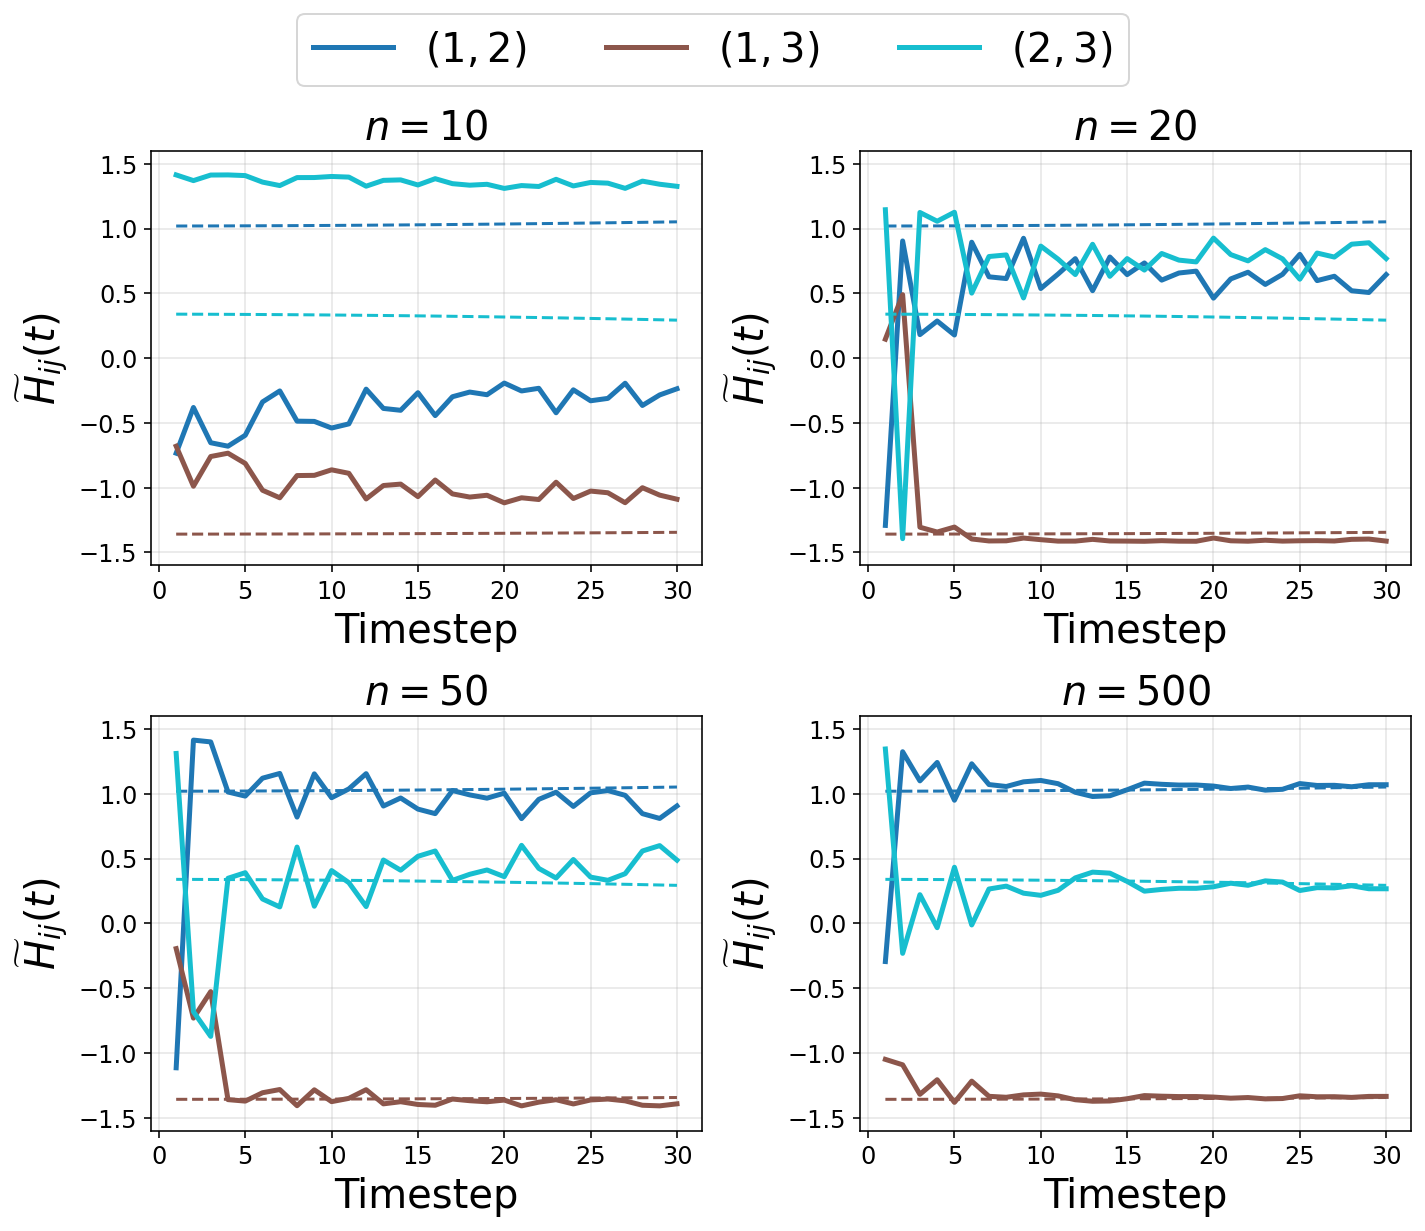

In [5]:
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 8), squeeze=False)
axes = axes.flatten()

legend_handles = []
for ax_idx, nd in enumerate(hessian_data):
    data0 = hessian_data[nd][0]
    tl = sorted(data0.keys())[:30]
    ax = axes[ax_idx]
    std_vals = standardize_across_entries(data0, tl, entry_keys)
    std_omega = standardize_omega_across_entries(omega_traces, entry_keys, len(tl))
    for c_idx, (i, j) in enumerate(entry_keys):
        line, = ax.plot(tl, std_vals[(i, j)],
                        color=colors[c_idx], linewidth=2.5, label=entry_labels[c_idx])
        ax.plot(tl, std_omega[(i, j)],
                color=colors[c_idx], linewidth=1.5, linestyle="--")
        if ax_idx == 0:
            legend_handles.append(line)
    ax.set_title(rf"$n={n_values[ax_idx]}$", fontsize=20)
    ax.set_xlabel("Timestep", fontsize=20)
    ax.set_ylabel(r"$\widetilde H_{ij}(t)$", fontsize=20)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-1.6, 1.6])

for k in range(len(hessian_data), len(axes)):
    axes[k].set_visible(False)

fig.legend(legend_handles, entry_labels, loc="upper center",
           ncol=len(legend_handles), fontsize=20, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

## Figure — $\vert H_{ij}(t) \vert$ for 3-dimensional Gaussian distribution

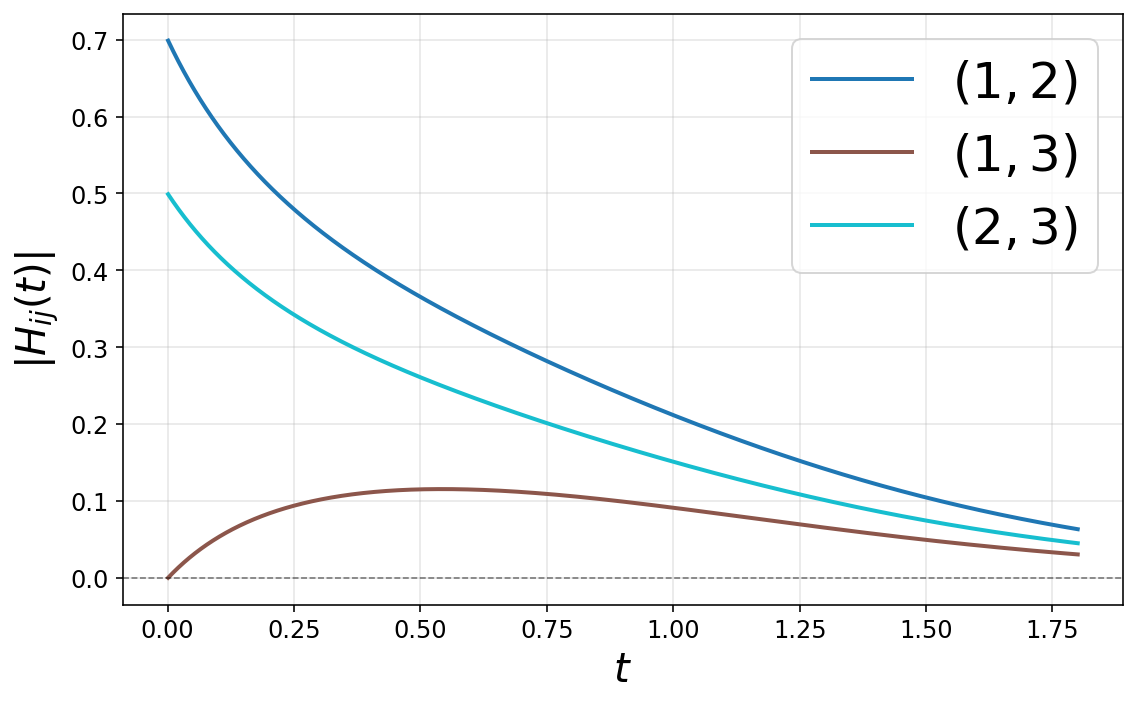

In [6]:
t_grid = np.linspace(0.001, 1.8, 5000)
mu_c = np.exp(-t_grid)
sigma_c = np.sqrt(1.0 - np.exp(-2 * t_grid))

omega_c = {p: [] for p in pairs}
for k in range(len(t_grid)):
    Sigma_t = mu_c[k] ** 2 * Sigma_0 + sigma_c[k] ** 2 * np.eye(D)
    Omega_t = np.linalg.inv(Sigma_t)
    for (i, j) in pairs:
        omega_c[(i, j)].append(Omega_t[i, j])
for key in omega_c:
    omega_c[key] = np.array(omega_c[key])

fig, ax = plt.subplots(figsize=(8, 5))
for idx, (i, j) in enumerate(pairs):
    ax.plot(t_grid, np.abs(omega_c[(i, j)]),
            color=colors[idx], linewidth=2, label=entry_labels[idx])
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel(r"$t$", fontsize=20)
ax.set_ylabel(r"$\vert H_{ij}(t)\vert$", fontsize=20)
ax.tick_params(labelsize=12)
ax.legend(loc="upper right", fontsize=25)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Figure — DDPM noise schedule used in our experiments

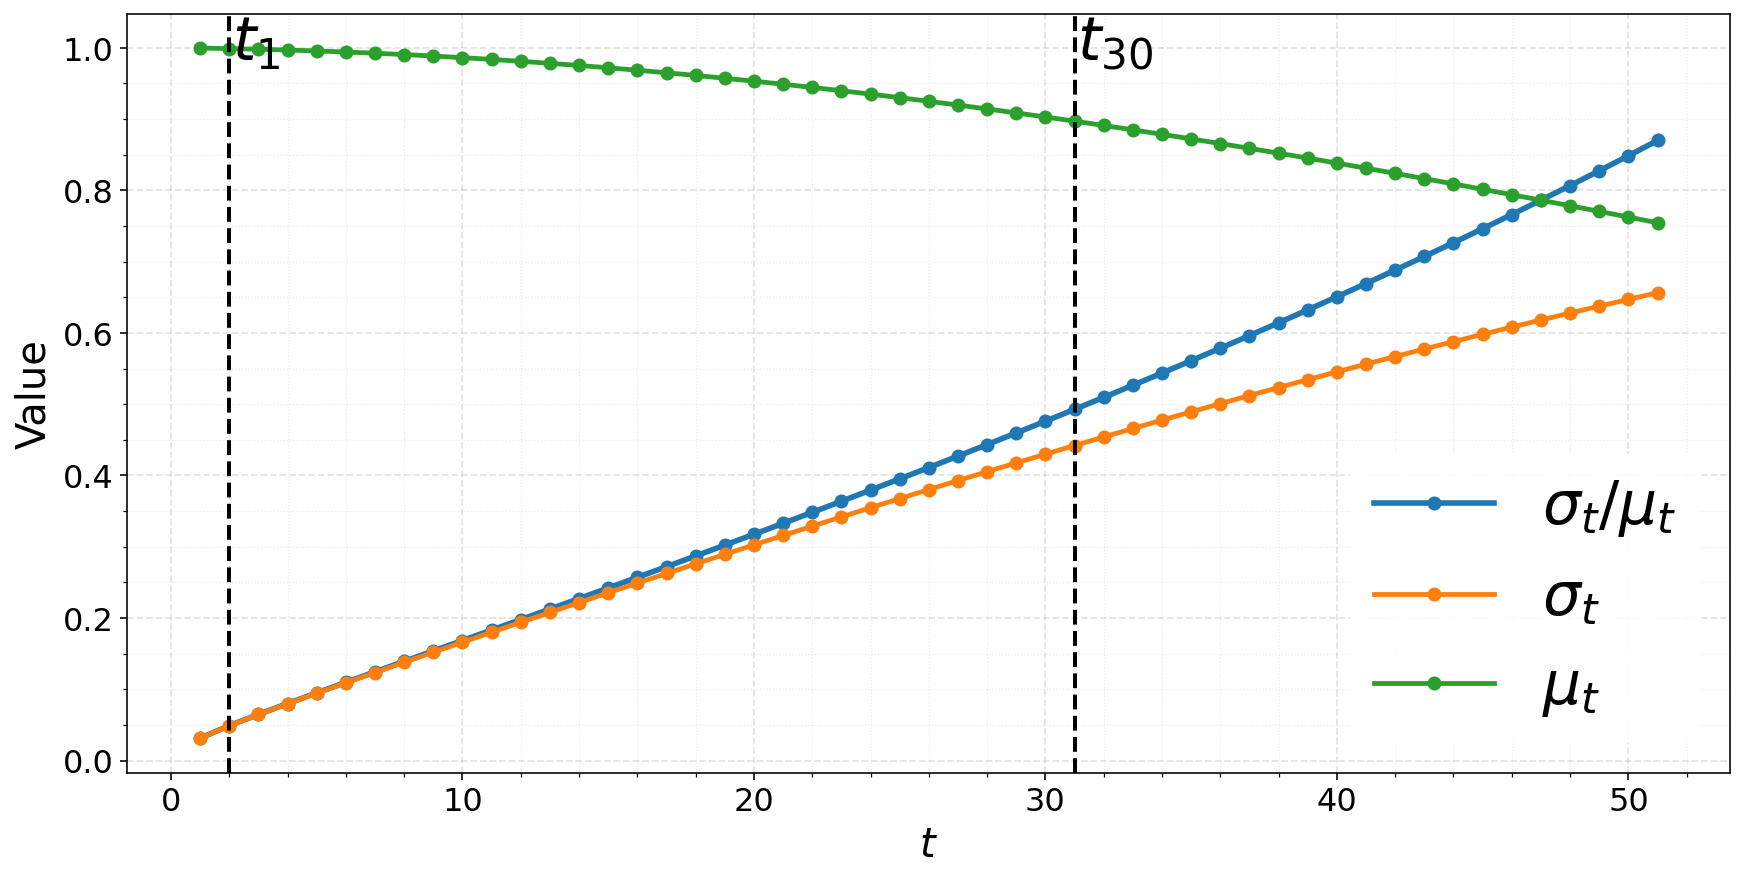

In [7]:
# Full schedule over t = 0..50 (independent of the t=1..30 grid used above)
sched_t = list(range(0, 51))
t_axis = np.arange(len(diffusion.alphas_bar))+1
abar_full = np.asarray(diffusion.alphas_bar)
mu_full = np.sqrt(abar_full)                 # μ_t = √ᾱ_t
sigma_full = np.sqrt(1.0 - abar_full)        # σ_t = √(1-ᾱ_t)
ratio_full = sigma_full / (mu_full + 1e-12)  # σ_t / μ_t

plt.rcParams.update({
    "font.size": 20, "axes.titlesize": 28, "axes.labelsize": 20,
    "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 30,
    "text.usetex": False,
})

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sched_colors = ["tab:blue", "tab:orange", "tab:green"]
ax.plot(t_axis[sched_t], ratio_full[sched_t], lw=2.8, color=sched_colors[0],
        marker="o", label=r"$\sigma_t/\mu_t$")
ax.plot(t_axis[sched_t], sigma_full[sched_t], lw=2.4, color=sched_colors[1],
        marker="o", label=r"$\sigma_t$")
ax.plot(t_axis[sched_t], mu_full[sched_t], lw=2.4, color=sched_colors[2],
        marker="o", label=r"$\mu_t$")

for v in (2, 31):
    ax.axvline(v, ls="--", lw=2.0, color="black")
    ax.text(v + 0.1, ax.get_ylim()[1], rf"$t_{{{v-1}}}$",
            color="black", va="top", ha="left", fontsize=30)

ax.set_xlabel(r"$t$")
ax.set_ylabel("Value")
ax.grid(True, which="major", linestyle="--", linewidth=0.9, alpha=0.35)
ax.grid(True, which="minor", linestyle=":", linewidth=0.6, alpha=0.25)
ax.minorticks_on()
leg = ax.legend(loc="lower right", frameon=True, fontsize=30)
leg.get_frame().set_alpha(0.9)
leg.get_frame().set_linewidth(0.0)
plt.show()